# **Part 1: Exploratory Data Analysis (EDA)**

###    Objective: To understand the dataset's structure, characteristics, and relationships between features.

###    Task: Start by loading the dataset into a pandas DataFrame. Explore the data with different commands.

       Hint: Use pd.read_csv() to load the data, then .head() and .info().

###    Task: The target variable "target" indicates the presence of heart disease. Visualize the distribution of this variable using a bar chart to see if the classes are balanced.

        Hint: Use .value_counts()

###    Task: Create a correlation matrix of all the features in the dataset and display it as a heatmap. This will help identify which variables are most strongly related to each other.

        Hint: Use df.corr() to create a heatmap.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

In [5]:
df = pd.read_csv('data/cleaned_starbucks.csv')

In [6]:
df.head()

,Beverage_category,Beverage,Beverage_prep,Calories,Total Fat (g),Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g),Vitamin A (% DV),Vitamin C (% DV),Calcium (% DV),Iron (% DV),Caffeine (mg)
0,Coffee,Brewed Coffee,Short,3,0.1,0.0,0.0,0,5,0,0,0,0.3,0,0,0,0.0,175.0
1,Coffee,Brewed Coffee,Tall,4,0.1,0.0,0.0,0,10,0,0,0,0.5,0,0,0,0.0,260.0
2,Coffee,Brewed Coffee,Grande,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0,0,0,0.0,330.0
3,Coffee,Brewed Coffee,Venti,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0,0,2,0.0,410.0
4,Classic Espresso Drinks,Caffè Latte,Short Nonfat Milk,70,0.1,0.1,0.0,5,75,10,0,9,6.0,10,0,20,0.0,75.0


In [24]:
df.dtypes

Beverage_category              str
Beverage                       str
Beverage_prep                  str
Calories                     int64
Total Fat (g)              float64
Trans Fat (g)              float64
Saturated Fat (g)          float64
Sodium (mg)                  int64
Total Carbohydrates (g)      int64
Cholesterol (mg)             int64
Dietary Fibre (g)            int64
Sugars (g)                   int64
Protein (g)                float64
Vitamin A (% DV)             int64
Vitamin C (% DV)             int64
Calcium (% DV)               int64
Iron (% DV)                float64
Caffeine (mg)              float64
dtype: object

In [16]:
df['Caffeine (mg)'] = df['Caffeine (mg)'].fillna(0)

# **Part 2: Model Training**

###    Objective: To prepare the data and train a classification model.

###    Task: Separate the dataset into two variables: X for the features (all columns except target) and y for the target variable (target column).

        Hint: Use .drop() to create the feature matrix X and simple indexing to create the target vector y.

###    Task: Split the X and y data into training and testing sets. Use an 80/20 split, where 80% is for training and 20% for testing.

        Hint: Use sklearn.model_selection.train_test_split().

###    Task: Import the RandomForestClassifier from scikit-learn. Instantiate the model and train it using the training data you created in the previous step.

        EHint: Use RandomForestClassifier() to create an instance, then .fit() on the training data.

In [42]:
import pandas as pd

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# THEN split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42
)

# Train model
from sklearn.ensemble import RandomForestClassifier   # likely correct model

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
rf.score(X_train, y_train)

1.0

In [44]:
rf.score(X_test, y_test)

0.6666666666666666

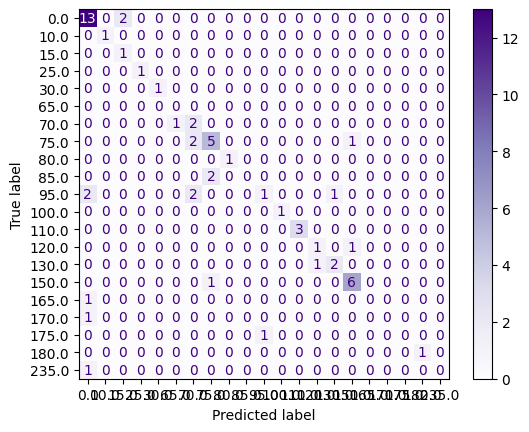

In [45]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap = 'Purples');

# **Part 3: Model Evaluation**

###    Objective: To evaluate how well the trained model performs on new, unseen data.

###    Task: Use your trained Random Forest model to make predictions on the test data. Store these predictions in a new variable.

        Hint: Use the .predict() method on your trained model with the test features.

###    Task: Calculate and print the accuracy of your model's predictions on the test set.

        Hint: Use sklearn.metrics.accuracy_score().

###    Task: Create and display a confusion matrix for your model's predictions to better understand its performance. A confusion matrix shows the number of correct and incorrect predictions for each class.

        Hint: Use sklearn.metrics.confusion_matrix().

In [49]:
#Write your code here
preds = rf.predict(X_test)

In [50]:
preds[:5]

array([ 95.,  75., 150.,  70.,   0.])

In [51]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, preds)

0.6833333333333333

In [59]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, preds))

[[15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  2  5  0  0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  3  0  0  0  1  0  0  0  0  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  2  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0]
 [ 0  0  0

# **Part 4: Feature Importance**

###    Objective: To identify which features were most influential in the model's predictions.

###    Task: Extract the feature importances from your trained Random Forest model. Create a pandas Series from these importances, and then visualize the top features using a bar chart.

        Hint: Access model.feature_importances_. Create a pd.Series from this, and use sns.barplot() to plot it.

In [ ]:
#Write your code here

In [61]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)

In [62]:
feat_imp = feat_imp.sort_values(ascending=False)

/tmp/ipykernel_12694/1133178093.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Purples")


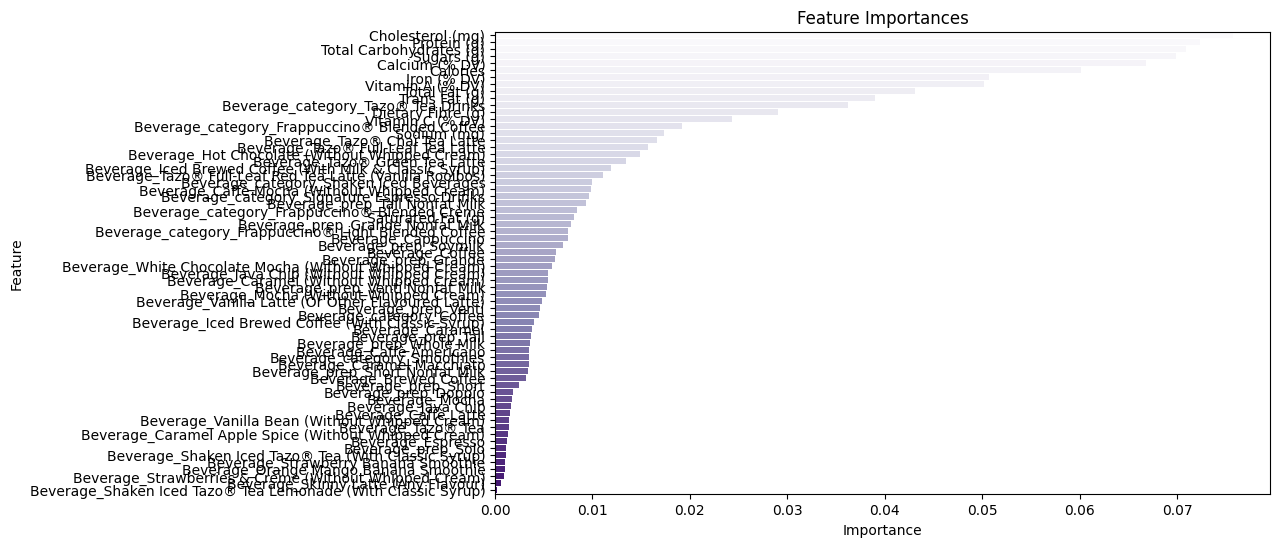

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Purples")
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# **Provide insights & conclusions:**

### - How accurate was the RandomForest model?
### - What about the precision and recall for both classes?
### - What was the most influential/important factors in the model?


In [ ]:
# Idk wtf is going on LOL